In [26]:
import pandas as pd

def get_tokenized_sentences(file_name: str):
    """
    Generator that yields tokenized sentences (lists of tokens) 
    from a tokenized parquet file.
    
    Assumes parquet has a column 'tokens' where each entry
    is a list of tokens (or a string that can be split).
    """
    df = pd.read_parquet(file_name)
    for row in df["tokens"]:
        if isinstance(row, str):
            # If tokens are stored as comma-separated string
            yield row.split(",")
        else:
            # Already stored as a list
            yield row


In [27]:
import glob

# List all 10 parquet files
parquet_files = glob.glob("../Lab 3/tokenized_gujarati_corpus/gujarati_tokenized_batch_*.parquet")

In [28]:
from typing import Iterator
from math import log2

def get_tokenized_sentences(file_name: str, column: str = "tokenized_sentence"):
    df = pd.read_parquet(file_name)
    for row in df[column]:
        if isinstance(row, str):
            yield row.split(",")
        else:
            yield row


class UnigramCounter:
    def __init__(self, file_name: str, column: str = "tokenized_sentence") -> None:
        """
        Initialize unigram counter from tokenized text and count number of unigrams in text
        :param file_name: path of tokenized text. Each line is a sentence with tokens separated by comma.
        """
        self.sentence_generator = get_tokenized_sentences(file_name, column)
        self.count()

    def count(self) -> None:
        """
        Count number of unigrams in text, one sentence at a time
        """
        self.sentence_count = 0
        self.token_count = 0
        self.counts = {}

        for sentence in self.sentence_generator:
            self.sentence_count += 1
            self.token_count += len(sentence)
            for unigram in sentence:
                self.counts[unigram] = self.counts.get(unigram, 0) + 1


class UnigramModel:
    def __init__(self, train_counter: UnigramCounter) -> None:
        """
        Initialize unigram model from unigram counter, count the number of unique unigrams (vocab)
        :param train_counter: counted unigram counter
        """
        self.counter = train_counter
        self.counts = train_counter.counts.copy()
        self.counts['[UNK]'] = 0
        self.vocab = set(self.counts.keys())
        self.vocab_size = len(self.vocab)

    def train(self, k: int = 1) -> None:
        """
        For each unigram in the vocab, calculate its probability in the text
        :param k: smoothing pseudo-count for each unigram
        """
        self.probs = {}
        for unigram, unigram_count in self.counts.items():
            prob_nom = unigram_count + k
            prob_denom = self.counter.token_count + k * self.vocab_size
            self.probs[unigram] = prob_nom / prob_denom

    def evaluate(self, evaluation_counter: UnigramCounter) -> float:
        """
        Calculate the average log likelihood of the model on the evaluation text
        :param evaluation_counter: unigram counter for the text on which the model is evaluated on
        :return: average log likelihood that the unigram model assigns to the evaluation text
        """
        test_log_likelihood = 0
        test_counts = evaluation_counter.counts

        for unigram, test_count in test_counts.items():
            if unigram not in self.vocab:
                unigram = '[UNK]'
            train_prob = self.probs[unigram]
            log_likelihood = test_count * log2(train_prob)
            test_log_likelihood += log_likelihood

        avg_test_log_likelihood = test_log_likelihood / evaluation_counter.token_count
        return avg_test_log_likelihood

In [29]:
aggregated_counter = UnigramCounter.__new__(UnigramCounter)
aggregated_counter.sentence_count = 0
aggregated_counter.token_count = 0
aggregated_counter.counts = {}

In [30]:
# Aggregate counts across all files
for file_path in parquet_files:
    counter = UnigramCounter(file_path)
    aggregated_counter.sentence_count += counter.sentence_count
    aggregated_counter.token_count += counter.token_count
    for token, count in counter.counts.items():
        aggregated_counter.counts[token] = aggregated_counter.counts.get(token, 0) + count

In [31]:
import pandas as pd

df = pd.read_parquet(parquet_files[0])
print(df.columns)

Index(['original_sentence', 'tokenized_sentence', 'token_count'], dtype='object')


In [32]:
model = UnigramModel(aggregated_counter)
model.train(k=1)

/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 67 (C) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 111 (o) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 117 (u) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **

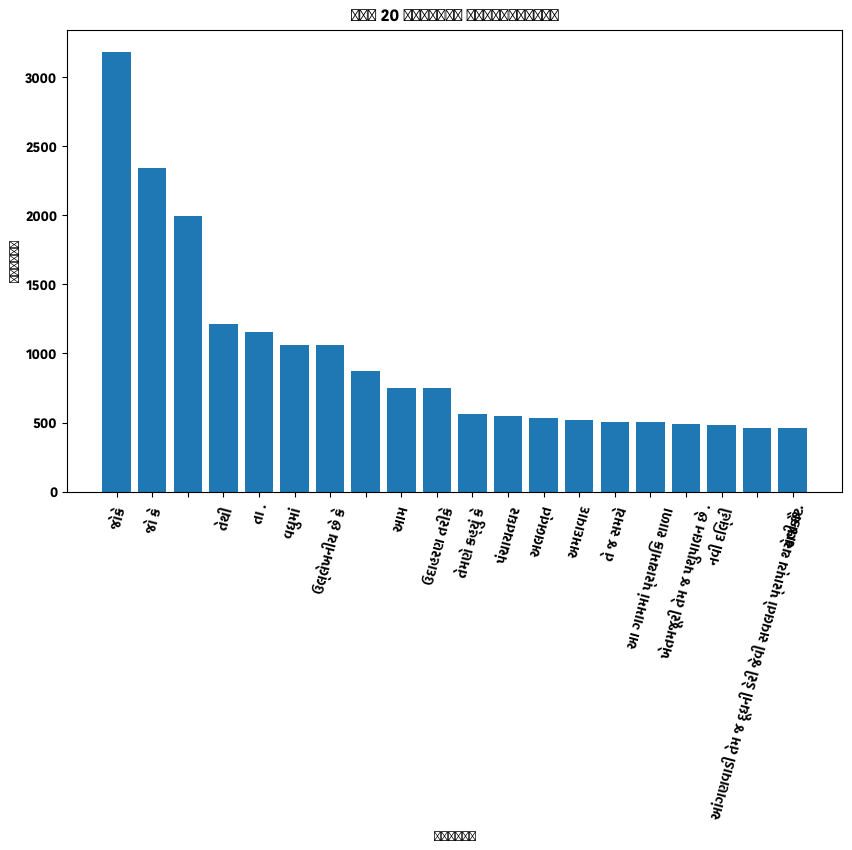

/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 80 (P) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 98 (b) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 121 (y) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)


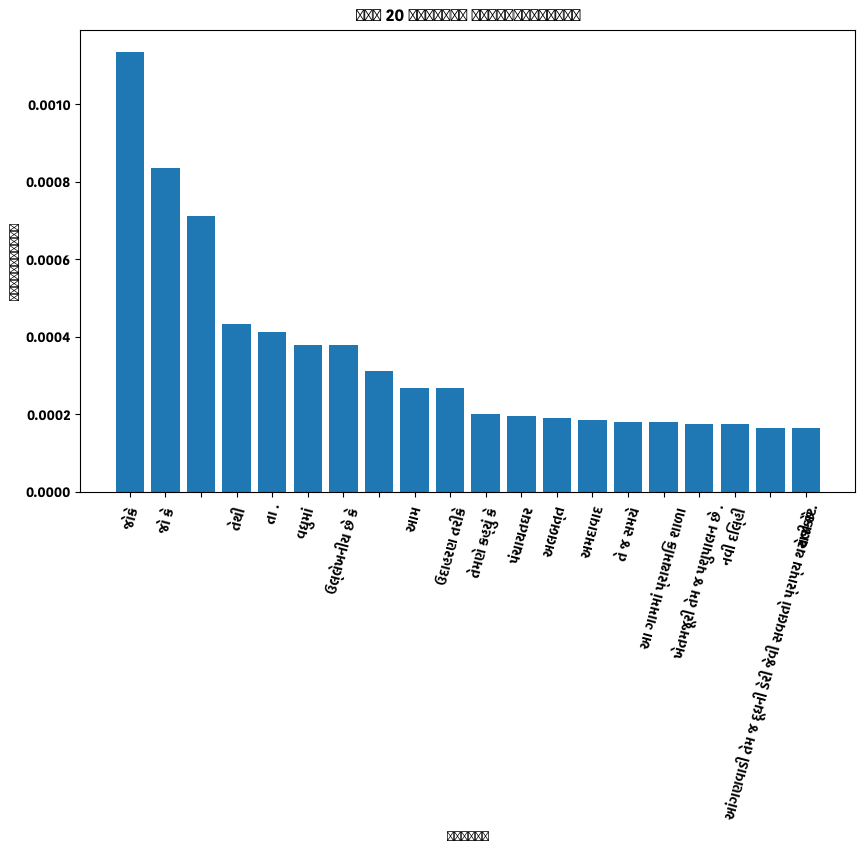

Font 'default' does not have a glyph for 'x' [U+78], substituting with a dummy symbol.
Font 'default' does not have a glyph for 'x' [U+78], substituting with a dummy symbol.
Font 'default' does not have a glyph for 'x' [U+78], substituting with a dummy symbol.
Font 'default' does not have a glyph for 'x' [U+78], substituting with a dummy symbol.
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 90 (Z) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 102 (f) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 76 (L) missing from font(s) Kohinoor Gujarati.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/vatsalbateriwala/.local/lib/python3.11/site-

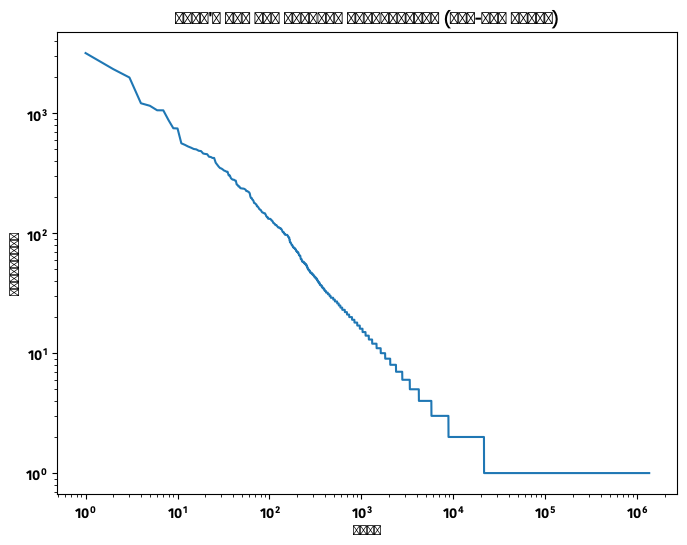

In [33]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Kohinoor Gujarati'

# 1. Top N frequent tokens
top_n = 20
sorted_tokens = sorted(model.counter.counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
tokens, counts = zip(*sorted_tokens)
plt.figure(figsize=(10,6))
plt.bar(tokens, counts)
plt.xticks(rotation=75)
plt.title(f"Top {top_n} Unigram Frequencies")
plt.xlabel("Tokens")
plt.ylabel("Counts")
plt.show()

# 2. Unigram probabilities for top N tokens
probs = [model.probs[token] for token in tokens]
plt.figure(figsize=(10,6))
plt.bar(tokens, probs)
plt.xticks(rotation=75)
plt.title(f"Top {top_n} Unigram Probabilities")
plt.xlabel("Tokens")
plt.ylabel("Probability")
plt.show()

# 4. Zipf's law plot (log-log)
ranks = list(range(1, len(model.counter.counts) +1))
freqs = [count for _, count in sorted(model.counter.counts.items(), key=lambda x: x[1], reverse=True)]
plt.figure(figsize=(8,6))
plt.loglog(ranks, freqs)
plt.title("Zipf's Law for Unigram Frequencies (Log-Log Scale)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()


In [34]:
import matplotlib.font_manager as fm

for f in fm.fontManager.ttflist:
    if "Gujarati" in f.name:
        print(f.name)


Kohinoor Gujarati
Gujarati Sangam MN
Gujarati MT
Sama Gujarati


In [37]:
import numpy as np
from typing import List, Tuple, Callable, Union
from nltk.util import ngrams


class NgramCounter:
    def __init__(self, file_name: str) -> None:
        """
        Initialize n-gram counter from tokenized text and count number of n-grams in text
        :param file_name: path of tokenized text. Each line is a sentence with tokens separated by comma.
        """
        self.sentence_generator = get_tokenized_sentences(file_name)
        self.count()

    def count(self) -> None:
        """
        Count number of n-grams in text (both overall and starting n-grams), one sentence at a time
        """
        self.sentence_count = 0
        self.token_count = 0
        self.counts = {}
        self.start_counts = {}

        for sentence in self.sentence_generator:
            self.sentence_count += 1
            self.token_count += len(sentence)

            for ngram_length in range(1, 6):
                for ngram_position, ngram in enumerate(ngrams(sentence, ngram_length)):
                    if ngram_position == 0:
                        self.start_counts[ngram] = self.start_counts.get(ngram, 0) + 1
                    self.counts[ngram] = self.counts.get(ngram, 0) + 1


class NgramModel:
    def __init__(self, train_counter: NgramCounter) -> None:
        """
        Initialize unigram model from unigram counter, count the number of unique unigrams (vocab)
        :param train_counter: counted n-gram counter
        """
        self.counter = train_counter
        self.counts = train_counter.counts
        self.start_counts = train_counter.start_counts
        self.vocab_size = len(list(ngram for ngram in self.counts.keys() if len(ngram) == 1))
        self.uniform_prob = 1 / (self.vocab_size + 1)

    def calculate_unigram_prob(self, unigram: Tuple[str]) -> None:
        """
        Calculate conditional probability for a unigram
        :param unigram: length-1 tuple containing the unigram
        """
        if unigram in self.start_counts:
            prob_nom = self.start_counts[unigram]
            prob_denom = self.counter.sentence_count
            self.start_probs[unigram] = prob_nom / prob_denom

        prob_nom = self.counts[unigram]
        prob_denom = self.counter.token_count
        self.probs[unigram] = prob_nom / prob_denom

    def calculate_multigram_prob(self, ngram: Tuple[str]) -> None:
        """
        Calculate conditional probability for higher n-gram (multigram)
        :param ngram: tuple containing words of the n-gram
        """
        prevgram = ngram[:-1]
        if ngram in self.start_counts:
            prob_nom = self.start_counts[ngram]
            prob_denom = self.start_counts[prevgram]
            self.start_probs[ngram] = prob_nom / prob_denom

        prob_nom = self.counts[ngram]
        prob_denom = self.counts[prevgram]
        self.probs[ngram] = prob_nom / prob_denom

    def train(self) -> None:
        """
        For each n-gram, calculate its conditional probability in the training text
        """
        self.probs = {}
        self.start_probs = {}
        for ngram in self.counts:
            if len(ngram) == 1:
                self.calculate_unigram_prob(ngram)
            else:
                self.calculate_multigram_prob(ngram)

    def evaluate(self, eval_file: str) -> np.ndarray:
        """
        Evaluate trained n-gram model on evaluation text
        :param eval_file: file path of tokenized evaluation text
        :return: probability matrix of evaluation text (number of words * number of models)
        """
        eval_token_count = sum(len(sentence) for sentence in get_tokenized_sentences(eval_file))
        prob_matrix = np.zeros(shape=(eval_token_count, 6))

        # Fill in uniform probability to first column of matrix
        prob_matrix[:, 0] = self.uniform_prob

        # Fill in n-gram probabilities row-by-row to the matrix
        row = 0
        for sentence in get_tokenized_sentences(eval_file):
            for token_position, token in enumerate(sentence):
                for ngram_length in range(1, 6):
                    ngram_start = token_position + 1 - ngram_length
                    ngram_end = token_position + 1
                    # For n-gram at start of sentence (negative start position)
                    if ngram_start < 0:
                        ngram = tuple(sentence[0:ngram_end])
                        prob_matrix[row, ngram_length] = self.start_probs.get(ngram, 0)
                    # For regular n-gram (non-negative start position)
                    else:
                        ngram = tuple(sentence[ngram_start:ngram_end])
                        prob_matrix[row, ngram_length] = self.probs.get(ngram, 0)
                row += 1

        return prob_matrix


def calculate_avg_ll(prob_matrix: np.ndarray, weights: List[float] = None, log_function: Callable = np.log2) -> float:
    """
    Calculate average log likelihood from weighted combination of columns in probability matrix of evaluation text
    :param prob_matrix: probability matrix of evaluation text
    :param weights: corresponding weight of each column
    :param log_function: log function to use (often np.log2 for base 2 log, or np.log for natural log)
    :return: average log likelihood from weighted combination of columns
    """
    n_models = prob_matrix.shape[1]
    if weights is None:
        weights = np.ones(n_models) / n_models
    interpolated_probs = np.sum(prob_matrix * weights, axis=1)
    average_log_likelihood = log_function(interpolated_probs).mean()
    return average_log_likelihood


def calculate_avg_ln(prob_matrix: np.array, weights: Union[List[float], np.array] = None) -> float:
    """
    Calculate average natural log likelihood of evaluation text with given interpolation weights
    :param prob_matrix: probability matrix of n_words x n_models
    :param weights: given weights for each model
    :return: average natural log of evaluation text with given weights
    """
    return calculate_avg_ll(prob_matrix, weights, log_function=np.log)

In [42]:
aggregated_counter = NgramCounter.__new__(NgramCounter)
aggregated_counter.sentence_count = 0
aggregated_counter.token_count = 0
aggregated_counter.counts = {}
aggregated_counter.start_counts = {}  # Add this

for file_path in parquet_files:
    counter = NgramCounter(file_path)
    aggregated_counter.sentence_count += counter.sentence_count
    aggregated_counter.token_count += counter.token_count

    for ngram, count in counter.counts.items():
        aggregated_counter.counts[ngram] = aggregated_counter.counts.get(ngram, 0) + count

    for ngram, count in counter.start_counts.items():
        aggregated_counter.start_counts[ngram] = aggregated_counter.start_counts.get(ngram, 0) + count

model = NgramModel(aggregated_counter)
model.train()


In [43]:
print(f"Model trained on {aggregated_counter.sentence_count} sentences with {aggregated_counter.token_count} tokens.")

Model trained on 999848 sentences with 1460336 tokens.


/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 108 (l) missing from font(s) Kohinoor Gujarati.
  plt.tight_layout()
/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 112 (p) missing from font(s) Kohinoor Gujarati.
  plt.tight_layout()
/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 70 (F) missing from font(s) Kohinoor Gujarati.
  plt.tight_layout()
/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 114 (r) missing from font(s) Kohinoor Gujarati.
  plt.tight_layout()
/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 101 (e) missing from font(s) Kohinoor Gujarati.
  plt.tight_layout()
/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 113 (q) missing from font(s) Kohinoor Gujarati.
  plt.ti

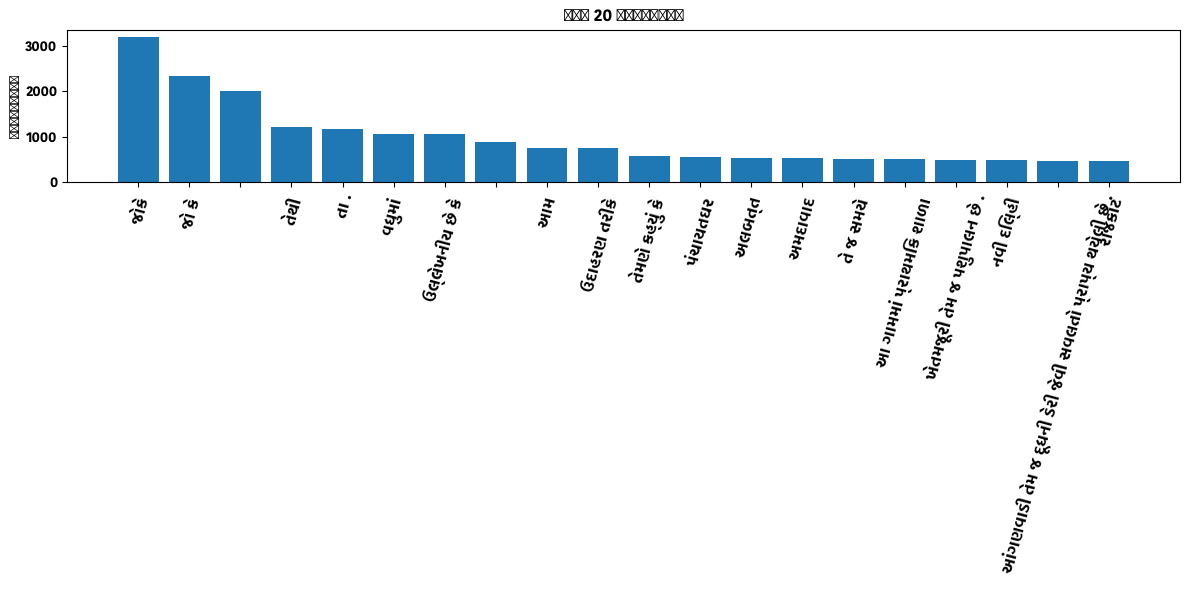

/var/folders/x8/79hcsbfd11344s7kn5xhb2wr0000gn/T/ipykernel_3953/129355304.py:13: UserWarning: Glyph 66 (B) missing from font(s) Kohinoor Gujarati.
  plt.tight_layout()


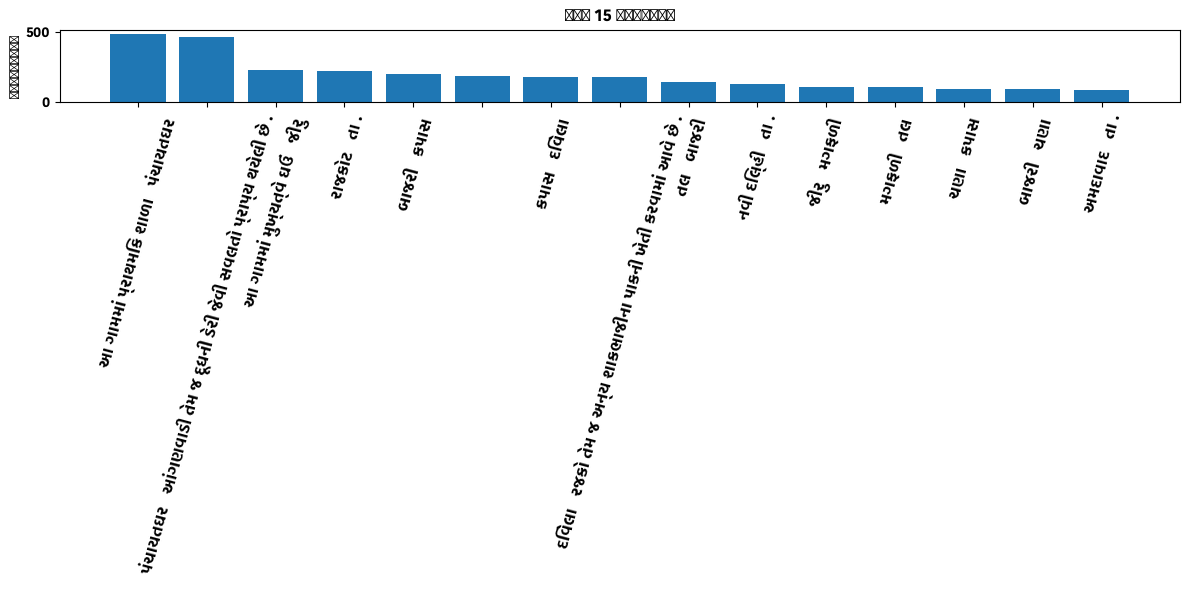

In [47]:
import matplotlib.pyplot as plt
rcParams['font.family'] = 'Kohinoor Gujarati'
def plot_top_ngrams(ngram_counts, n=10, title="Top N-grams"):
    top_ngrams = sorted(ngram_counts.items(), key=lambda x: x[1], reverse=True)[:n]
    ngrams_, counts = zip(*top_ngrams)
    ngrams_labels = [" ".join(ng) for ng in ngrams_]

    plt.figure(figsize=(12,6))
    plt.bar(ngrams_labels, counts)
    plt.xticks(rotation=75, fontsize=12)
    plt.title(title)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Example: Plot top 20 unigrams
unigram_counts = {k: v for k, v in aggregated_counter.counts.items() if len(k) == 1}
plot_top_ngrams(unigram_counts, n=20, title="Top 20 Unigrams")

# Example: Plot top 15 bigrams
bigram_counts = {k: v for k, v in aggregated_counter.counts.items() if len(k) == 2}
plot_top_ngrams(bigram_counts, n=15, title="Top 15 Bigrams")
